# 🌸 Iris Flower Classification

This project implements machine learning models to classify Iris flowers into three species (**Setosa, Versicolor, and Virginica**) using measurements of their sepal length, sepal width, petal length, and petal width.

## 📊 Dataset
The dataset contains 150 records with the following attributes:
- `SepalLengthCm`
- `SepalWidthCm`
- `PetalLengthCm`
- `PetalWidthCm`
- `Species` (Target Class)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Set plot styles
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 6)

In [2]:
# Load the dataset
df = pd.read_csv("Iris.csv")

# Display the first few rows
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
# Check dataset information
print("--- Dataset Info ---")
df.info()

# Check for missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())

# Drop the 'Id' column since it is not a feature for prediction
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])

# Check species distribution
print("\n--- Species Distribution ---")
print(df['Species'].value_counts())

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB

--- Missing Values ---
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

--- Species Distribution ---
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


## 📈 Exploratory Data Analysis (EDA)
Let's visualize the dataset to understand the relationship between features and species.

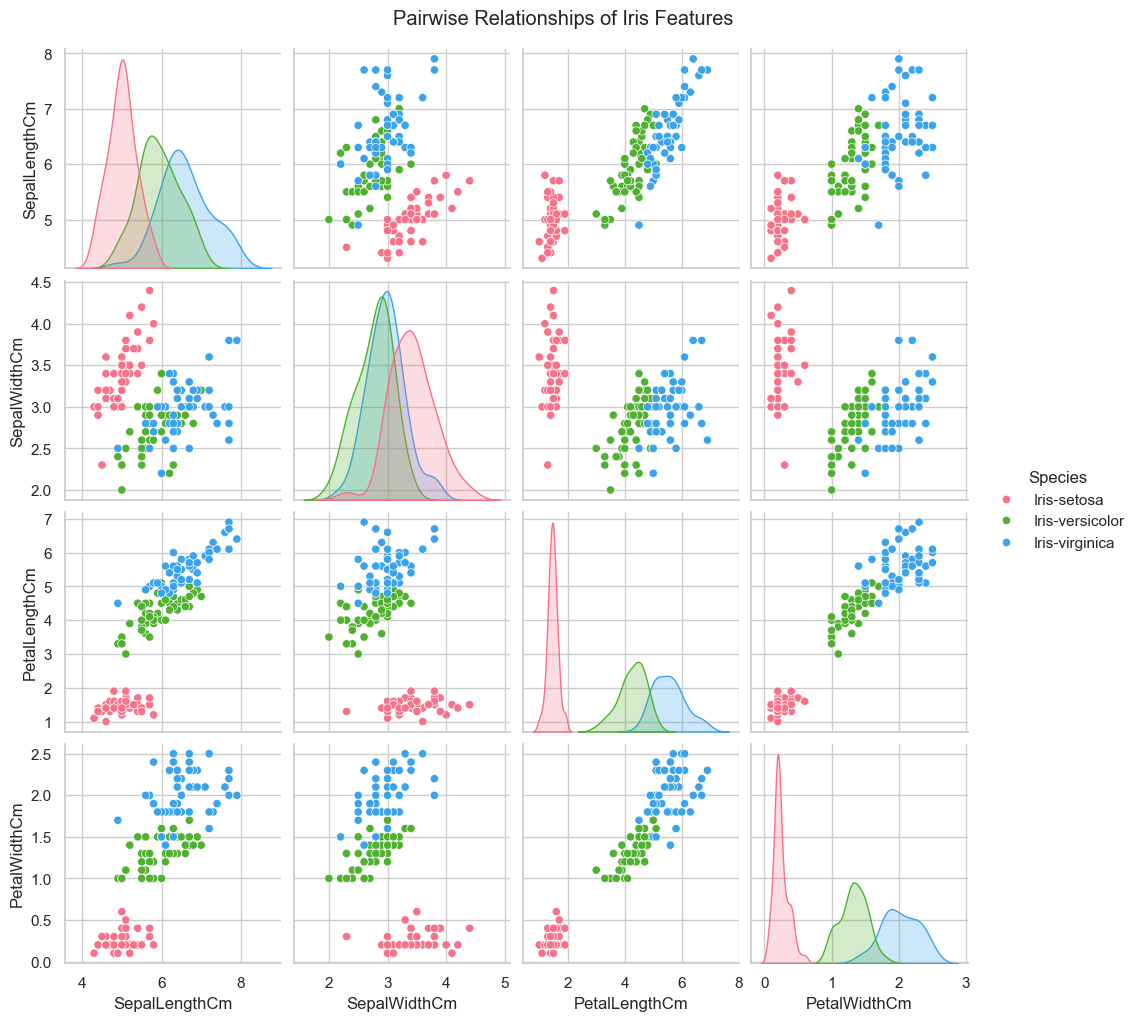

In [4]:
# Pairplot to see pairwise relationships
sns.pairplot(df, hue="Species", palette="husl")
plt.suptitle("Pairwise Relationships of Iris Features", y=1.02)
plt.savefig("iris_pairplot.png", dpi=300, bbox_inches="tight")
plt.show()

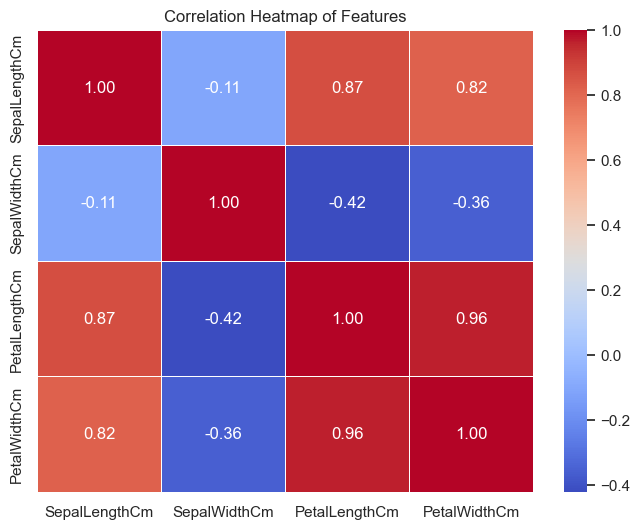

In [5]:
# Correlation heatmap for numerical features
plt.figure(figsize=(8, 6))
numeric_df = df.drop(columns=['Species'])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Features")
plt.savefig("iris_correlation.png", dpi=300, bbox_inches="tight")
plt.show()

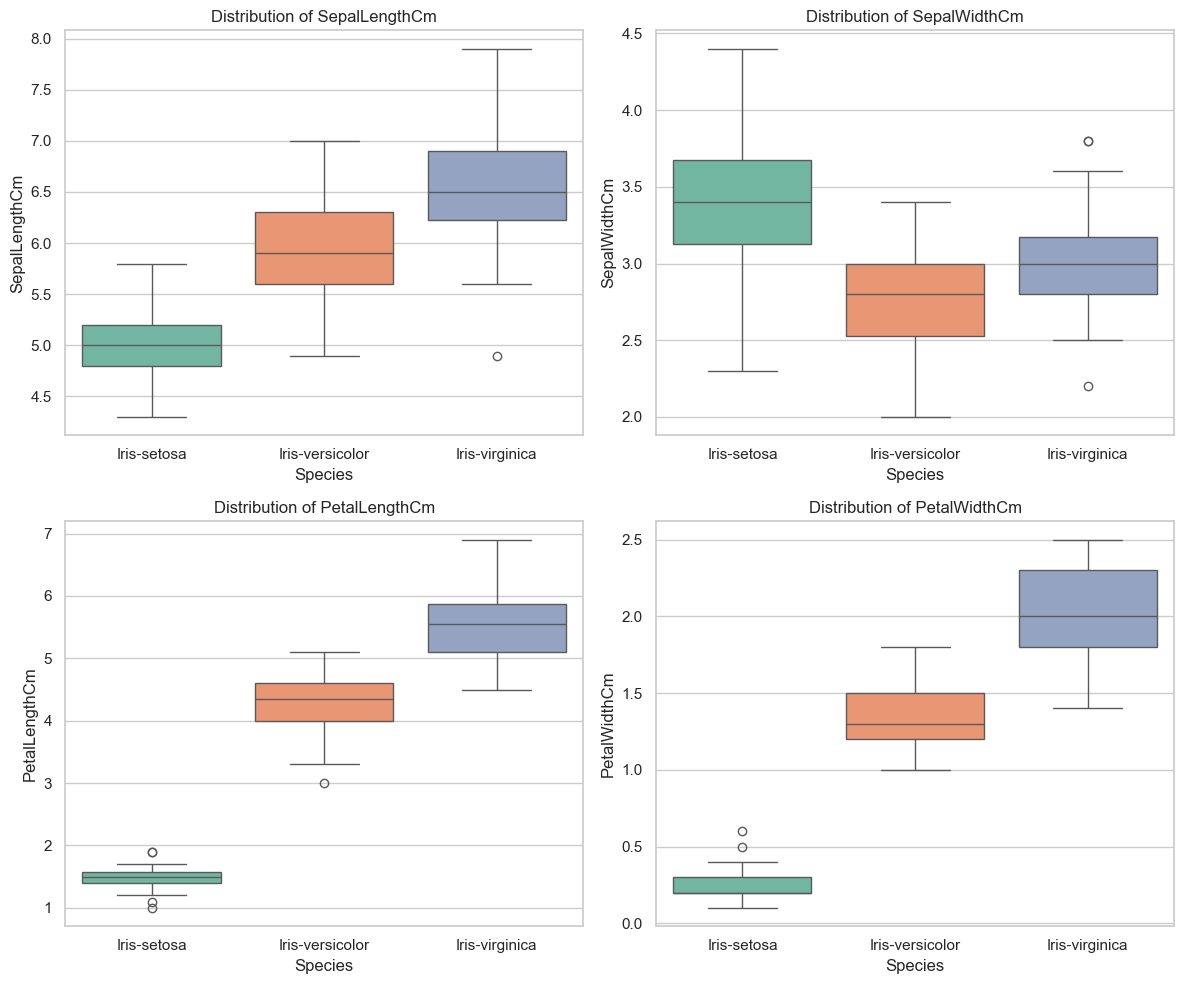

In [6]:
# Boxplots to view feature distributions by species
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
features = df.columns[:-1]

for i, feature in enumerate(features):
    row, col = i // 2, i % 2
    sns.boxplot(ax=axes[row, col], data=df, x="Species", y=feature, palette="Set2", hue="Species", legend=False)
    axes[row, col].set_title(f"Distribution of {feature}")

plt.tight_layout()
plt.savefig("iris_boxplots.png", dpi=300, bbox_inches="tight")
plt.show()

## ⚙️ Data Preprocessing & Split
We will split the features and target variable, perform a train-test split (80% training / 20% testing), and apply feature scaling.

In [7]:
# Features and Target
X = df.drop(columns=['Species'])
y = df['Species']

# Train-Test Split (stratified by class to keep balanced representation)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training set size: 120
Testing set size: 30


## 🤖 Model Training & Comparison
We will train and compare four models:
1. **Logistic Regression**
2. **K-Nearest Neighbors (KNN)**
3. **Support Vector Machine (SVM)**
4. **Random Forest Classifier**

In [8]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=200, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Support Vector Machine": SVC(kernel="rbf", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Store accuracies
model_accuracies = {}

# Evaluate each model
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    model_accuracies[name] = acc
    
    print(f"=== {name} ===")
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("-" * 50)

=== Logistic Regression ===
Accuracy: 0.9333

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30

--------------------------------------------------
=== K-Nearest Neighbors ===
Accuracy: 0.9333

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30

-------

## 📊 Model Performance Comparison
Let's visualize and compare the accuracy scores of all models.

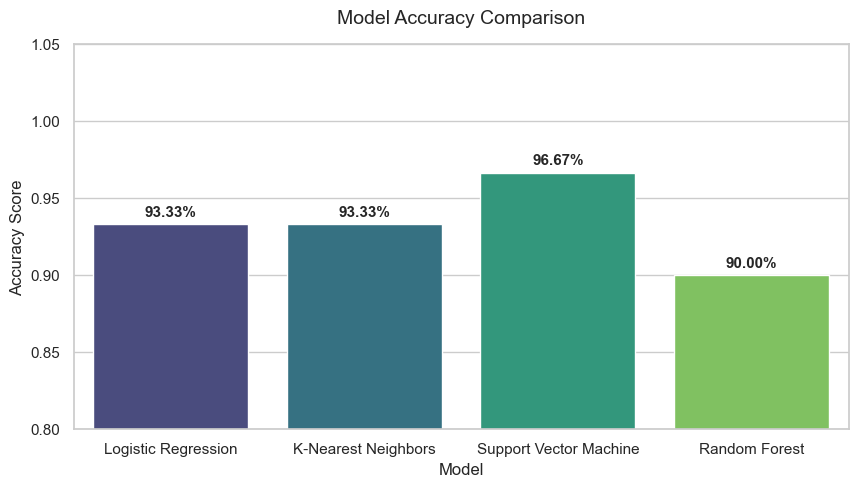

In [9]:
# Plot model accuracies
plt.figure(figsize=(10, 5))
model_names = list(model_accuracies.keys())
model_scores = list(model_accuracies.values())
sns.barplot(x=model_names, y=model_scores, palette="viridis", hue=model_names, legend=False)
plt.ylim(0.8, 1.05)
plt.title("Model Accuracy Comparison", fontsize=14, pad=15)
plt.ylabel("Accuracy Score", fontsize=12)
plt.xlabel("Model", fontsize=12)

for i, val in enumerate(model_scores):
    plt.text(i, val + 0.005, f"{val:.2%}", ha='center', fontweight='bold', fontsize=11)

plt.savefig("model_accuracy_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

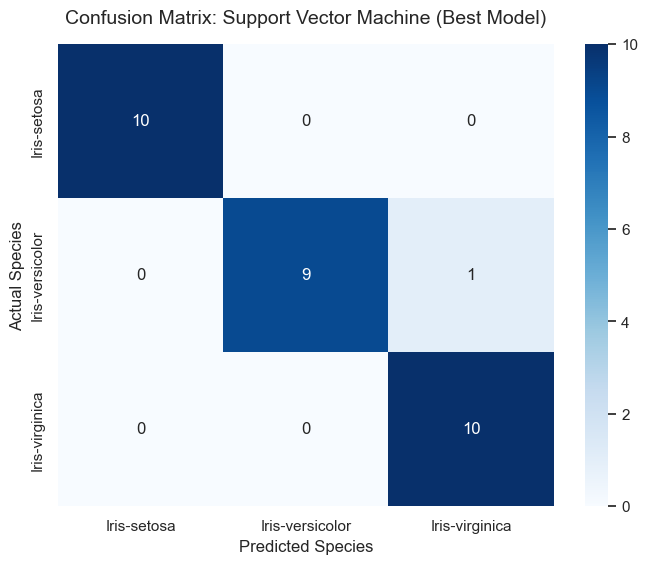

The best performing model on the test set is: Support Vector Machine with 96.67% accuracy!


In [10]:
# Find and evaluate the best model's confusion matrix
best_model_name = max(model_accuracies, key=model_accuracies.get)
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=best_model.classes_, 
            yticklabels=best_model.classes_)
plt.title(f"Confusion Matrix: {best_model_name} (Best Model)", fontsize=14, pad=15)
plt.ylabel("Actual Species", fontsize=12)
plt.xlabel("Predicted Species", fontsize=12)
plt.savefig("best_model_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"The best performing model on the test set is: {best_model_name} with {model_accuracies[best_model_name]:.2%} accuracy!")